<a href="https://colab.research.google.com/github/fknbtrd/netology_homework/blob/main/%D0%94%D0%97%20%D0%9E%D1%86%D0%B5%D0%BD%D0%BA%D0%B0%20%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D1%81%D1%82%D0%B8%20%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%2C%20%D0%BF%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5%2C%20%D1%80%D0%B5%D0%B3%D1%83%D0%BB%D1%8F%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

Загрузка данных и проверка пропусков

In [3]:
# загружаем файл
df = pd.read_csv('athletes.csv')

df.head()

# проверяем пропуски
df.isnull().sum()
# удаляем строки с пропусками
df = df.dropna()

print("Размер данных после удаления пропусков:", df.shape)

Размер данных после удаления пропусков: (10858, 11)


Кодирование категориальных признаков

In [4]:
# смотрим типы данных
df.info()
# кодируем целевую переменную:
# male = 1, female = 0
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df = pd.get_dummies(df, drop_first=True)

<class 'pandas.core.frame.DataFrame'>
Index: 10858 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10858 non-null  int64  
 1   name         10858 non-null  object 
 2   nationality  10858 non-null  object 
 3   sex          10858 non-null  object 
 4   dob          10858 non-null  object 
 5   height       10858 non-null  float64
 6   weight       10858 non-null  float64
 7   sport        10858 non-null  object 
 8   gold         10858 non-null  int64  
 9   silver       10858 non-null  int64  
 10  bronze       10858 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 1017.9+ KB


Кодирование категориальных признаков

In [5]:
X = df.drop('sex', axis=1)
y = df['sex']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Масштабирование

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Обучение модели

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

# вероятности принадлежности к классу 1
y_scores = model.predict_proba(X_test)[:, 1]

ROC-кривая (sklearn)

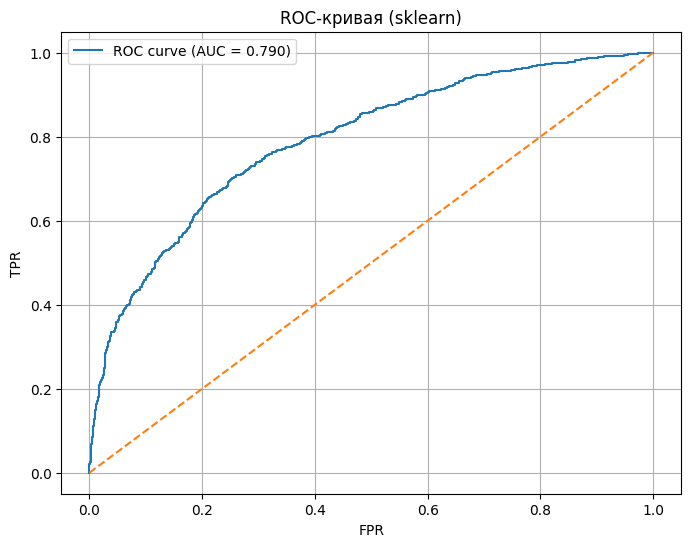

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')  # диагональ
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC-кривая (sklearn)")
plt.legend()
plt.grid()
plt.show()

Подсчёт метрик вручную

In [9]:
# функция для ручного подсчета TPR и FPR
def manual_roc(y_true, y_scores):

    thresholds = np.sort(y_scores)[::-1]

    tpr_list = []
    fpr_list = []

    P = sum(y_true == 1)
    N = sum(y_true == 0)

    for thresh in thresholds:

        y_pred = (y_scores >= thresh).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))

        TPR = TP / P
        FPR = FP / N

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return np.array(fpr_list), np.array(tpr_list)

fpr_manual, tpr_manual = manual_roc(y_test.values, y_scores)

Сравнение ROC-кривых

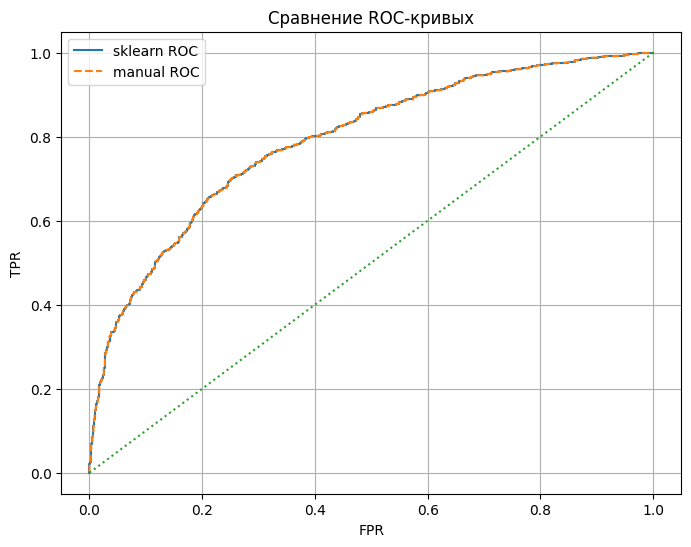

In [10]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="sklearn ROC")
plt.plot(fpr_manual, tpr_manual, linestyle='--', label="manual ROC")
plt.plot([0,1], [0,1], linestyle=':')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Сравнение ROC-кривых")
plt.legend()
plt.grid()
plt.show()

Precision-Recall кривая (вручную)

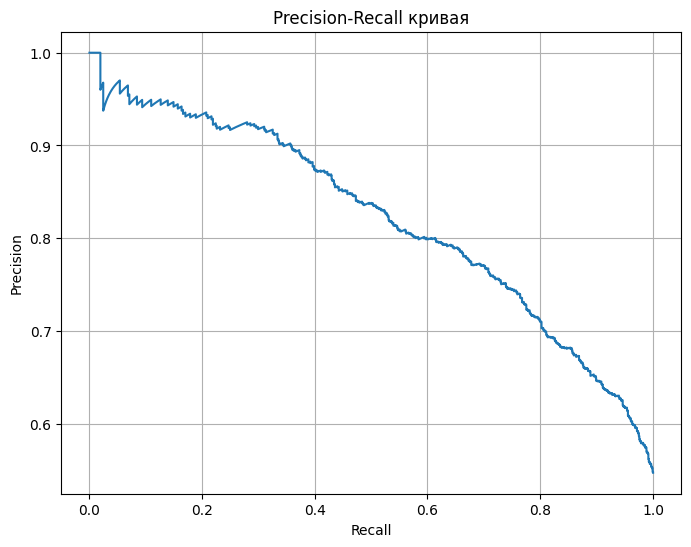

In [11]:
precision_list = []
recall_list = []

thresholds = np.sort(y_scores)[::-1]

for thresh in thresholds:

    y_pred = (y_scores >= thresh).astype(int)

    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    precision_list.append(precision)
    recall_list.append(recall)

plt.figure(figsize=(8,6))
plt.plot(recall_list, precision_list)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая")
plt.grid()
plt.show()

Выводы:

1. Как оценить качество по ROC-кривой?

Чем ближе кривая к левому верхнему углу, тем лучше модель.
Если кривая близка к диагонали — модель работает как рандомное угадывание.

2. Сравнение ручного и sklearn расчета

Графики совпадают, а значения по ROC одинаковые.
Это подтверждает корректность ручной реализации.

3. Может ли ROC-кривая быть ниже диагонали?

Да, может.
Это значит, что модель предсказывает хуже рандомного перебора.
Если просто поменять классы местами, качество станет выше диагонали.